In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import random_split, DataLoader
import torchvision
from torchvision import transforms
import random
import json

In [2]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(19)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


#### Данные и DataLoader

In [3]:
# Определение transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Загрузка датасета
train_full = torchvision.datasets.EMNIST(
    root='./data', 
    split='balanced', 
    train=True, 
    download=False, 
    transform=transform
)
test_dataset = torchvision.datasets.EMNIST(
    root='./data', 
    split='balanced', 
    train=False, 
    download=False, 
    transform=transform
)

In [4]:
class_names = train_full.classes
print("classes:", class_names)
print("train size:", len(train_full))
print("test size:", len(test_dataset))

classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
train size: 112800
test size: 18800


In [5]:
BATCH_SIZE = 256 if device.type == "cuda" else 64
NUM_WORKERS = 0 if os.name == "nt" else 2

# train/val split
val_ratio = 0.1
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

# Быстрый sanity-check
print("Batch shapes:")
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)
print("Диапазоны значений:")
print(f"x_batch: min={x_batch.min():.3f}, max={x_batch.max():.3f}, mean={x_batch.mean():.3f}")
print(f"y_batch: min={y_batch.min()}, max={y_batch.max()}, unique={len(torch.unique(y_batch))} классов")

Batch shapes:
x_batch: torch.Size([64, 1, 28, 28]) torch.float32
y_batch: torch.Size([64]) torch.int64
Диапазоны значений:
x_batch: min=-1.000, max=1.000, mean=-0.640
y_batch: min=0, max=46, unique=35 классов


#### Модель MLP и цикл обучения

In [6]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "") -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()
     

In [7]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,           # 784 пикселя (28×28)
        hidden_dims: tuple = (256, 128), # Больше нейронов для 47 классов
        num_classes: int = 47,              # EMNIST balanced: 47 классов
        activation: str = "relu",           # ReLU по умолчанию
        dropout_p: float = 0.0,             # Dropout для регуляризации
        use_batchnorm: bool = False,        # BatchNorm опционально
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]  # 28×28 → 784

        prev = input_dim
        for h in hidden_dims:    # Для каждого скрытого слоя
            layers.append(nn.Linear(prev, h))     # Linear(prev → h)
            if use_batchnorm:                     # BatchNorm (опционально)
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())            # Активация
            if dropout_p > 0:                     # Dropout (опционально)
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [9]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

epoch 01/20 | train loss=1.1425, acc=0.6632 | val loss=0.7498, acc=0.7670
epoch 02/20 | train loss=0.6662, acc=0.7870 | val loss=0.6247, acc=0.8003
epoch 03/20 | train loss=0.5640, acc=0.8126 | val loss=0.5761, acc=0.8099
epoch 04/20 | train loss=0.5086, acc=0.8277 | val loss=0.5471, acc=0.8195
epoch 05/20 | train loss=0.4742, acc=0.8382 | val loss=0.5340, acc=0.8240
epoch 06/20 | train loss=0.4481, acc=0.8433 | val loss=0.5336, acc=0.8298
epoch 07/20 | train loss=0.4263, acc=0.8505 | val loss=0.5240, acc=0.8323
epoch 08/20 | train loss=0.4081, acc=0.8545 | val loss=0.5222, acc=0.8279
epoch 09/20 | train loss=0.3951, acc=0.8590 | val loss=0.5243, acc=0.8297
epoch 10/20 | train loss=0.3811, acc=0.8609 | val loss=0.5168, acc=0.8364
epoch 11/20 | train loss=0.3714, acc=0.8656 | val loss=0.5494, acc=0.8282
epoch 12/20 | train loss=0.3610, acc=0.8669 | val loss=0.5408, acc=0.8268
epoch 13/20 | train loss=0.3514, acc=0.8703 | val loss=0.5287, acc=0.8327
epoch 14/20 | train loss=0.3438, acc=0

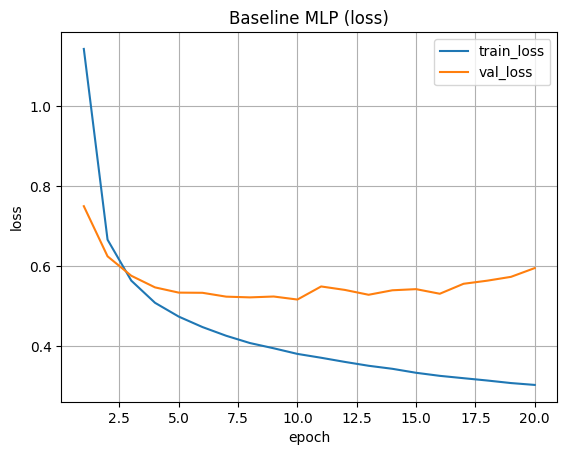

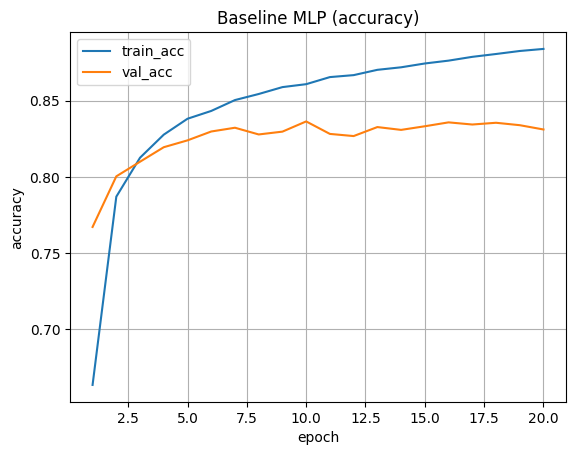

In [10]:
baseline = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_baseline, title="Baseline MLP")

In [11]:
def log_experiment(
    experiment_id: str,
    dataset: str,
    model: MLP,
    history: dict,
    epochs_trained: int,
    optimizer=None,
    runs_file: str = "artifacts/runs.csv",
    seed: int | None = None,
):
    if seed is None:
        try:
            seed = torch.initial_seed() % (2**31 - 1)
        except Exception:
            seed = -1  # "неизвестный" seed

    hidden_dims = getattr(model, "hidden_dims", "unknown")
    act_name = None
    for layer in model.net:
        if isinstance(layer, (nn.ReLU, nn.Tanh, nn.GELU)):
            act_name = layer.__class__.__name__.lower()
            break
    if act_name is None:
        act_name = "unknown"
    dropout = any(isinstance(layer, nn.Dropout) for layer in model.net)
    batchnorm = any(isinstance(layer, nn.BatchNorm1d) for layer in model.net)

    model_summary = f"hidden={hidden_dims} / {act_name} / dropout={dropout} / batchnorm={batchnorm}"

    best_idx = int(np.argmax(history["val_acc"]))
    best_val_acc = float(history["val_acc"][best_idx])
    best_val_loss = float(history["val_loss"][best_idx])

    opt_info = {
        "optimizer": "Adam",
        "lr": 1e-3,
        "momentum": 0,
        "weight_decay": 0
    }
    
    if optimizer is not None:
        # Читаем параметры из оптимизатора
        opt_info["optimizer"] = optimizer.__class__.__name__
        
        # lr из первого param_group
        if optimizer.param_groups[0].get('lr'):
            opt_info["lr"] = optimizer.param_groups[0]['lr']
        
        # momentum (только для SGD)
        if 'momentum' in optimizer.param_groups[0]:
            opt_info["momentum"] = optimizer.param_groups[0]['momentum']
        
        # weight_decay
        if optimizer.param_groups[0].get('weight_decay'):
            opt_info["weight_decay"] = optimizer.param_groups[0]['weight_decay']

    row = {
        "experiment_id": experiment_id,
        "dataset": dataset,
        "seed": seed,
        "model_summary": model_summary,
        **opt_info,  # ← вставляем optimizer info
        "epochs_trained": epochs_trained,
        "best_val_accuracy": best_val_acc,
        "best_val_loss": best_val_loss,
    }

    df_new = pd.DataFrame([row])
    try:
        df_existing = pd.read_csv(runs_file)
        df = pd.concat([df_existing, df_new], ignore_index=True)
    except FileNotFoundError:
        df = df_new

    df.to_csv(runs_file, index=False)
    print(f"{experiment_id} сохранён в {runs_file}, best_val_acc={best_val_acc:.4f} (epoch {best_idx+1})")

### E1 (base)

epoch 01/20 | train loss=1.1228, acc=0.6611 | val loss=0.8122, acc=0.7391
epoch 02/20 | train loss=0.6607, acc=0.7831 | val loss=0.6477, acc=0.7925
epoch 03/20 | train loss=0.5692, acc=0.8083 | val loss=0.5792, acc=0.8040
epoch 04/20 | train loss=0.5140, acc=0.8231 | val loss=0.5686, acc=0.8162
epoch 05/20 | train loss=0.4800, acc=0.8332 | val loss=0.5430, acc=0.8229
epoch 06/20 | train loss=0.4544, acc=0.8387 | val loss=0.5367, acc=0.8261
epoch 07/20 | train loss=0.4301, acc=0.8468 | val loss=0.5378, acc=0.8245
epoch 08/20 | train loss=0.4119, acc=0.8508 | val loss=0.5492, acc=0.8241
epoch 09/20 | train loss=0.3933, acc=0.8567 | val loss=0.5490, acc=0.8251
epoch 10/20 | train loss=0.3806, acc=0.8588 | val loss=0.5214, acc=0.8369
epoch 11/20 | train loss=0.3658, acc=0.8648 | val loss=0.5477, acc=0.8298
epoch 12/20 | train loss=0.3560, acc=0.8667 | val loss=0.5436, acc=0.8282
epoch 13/20 | train loss=0.3439, acc=0.8715 | val loss=0.5695, acc=0.8252
epoch 14/20 | train loss=0.3344, acc=0

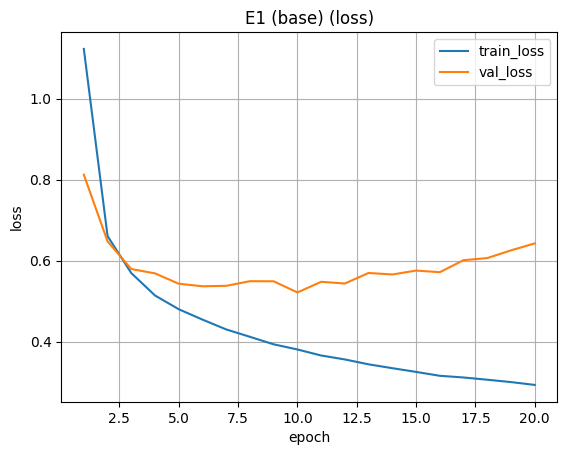

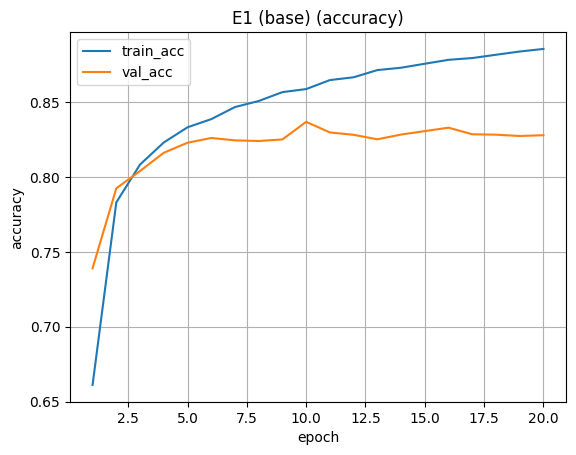

In [12]:
baseline_1 = MLP(hidden_dims=(128, 256, 128), dropout_p=0.0, use_batchnorm=False).to(device) # 3 скрытых слоя

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_1.parameters(), lr=1e-3)

history_baseline_1 = fit(
    baseline_1, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_baseline_1, title="E1 (base)")

In [13]:
dataset_name = "EMNIST"
log_experiment("E1", dataset_name, baseline_1, history_baseline_1, 20)

E1 сохранён в artifacts/runs.csv, best_val_acc=0.8369 (epoch 10)


### E2 (Dropout)

epoch 01/20 | train loss=1.8170, acc=0.4681 | val loss=1.0193, acc=0.6909
epoch 02/20 | train loss=1.3201, acc=0.5996 | val loss=0.8947, acc=0.7282
epoch 03/20 | train loss=1.2197, acc=0.6277 | val loss=0.8033, acc=0.7521
epoch 04/20 | train loss=1.1607, acc=0.6439 | val loss=0.7733, acc=0.7505
epoch 05/20 | train loss=1.1266, acc=0.6532 | val loss=0.7493, acc=0.7582
epoch 06/20 | train loss=1.0972, acc=0.6609 | val loss=0.7341, acc=0.7669
epoch 07/20 | train loss=1.0866, acc=0.6629 | val loss=0.7398, acc=0.7682
epoch 08/20 | train loss=1.0678, acc=0.6709 | val loss=0.7029, acc=0.7732
epoch 09/20 | train loss=1.0511, acc=0.6749 | val loss=0.6934, acc=0.7744
epoch 10/20 | train loss=1.0459, acc=0.6738 | val loss=0.6853, acc=0.7812
epoch 11/20 | train loss=1.0327, acc=0.6797 | val loss=0.6815, acc=0.7818
epoch 12/20 | train loss=1.0282, acc=0.6819 | val loss=0.6873, acc=0.7816
epoch 13/20 | train loss=1.0178, acc=0.6830 | val loss=0.6721, acc=0.7835
epoch 14/20 | train loss=1.0106, acc=0

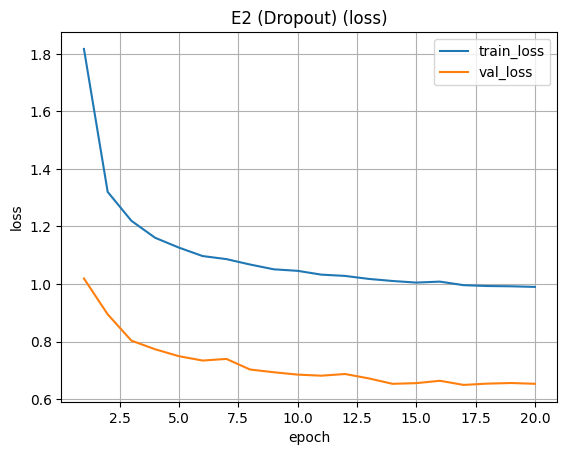

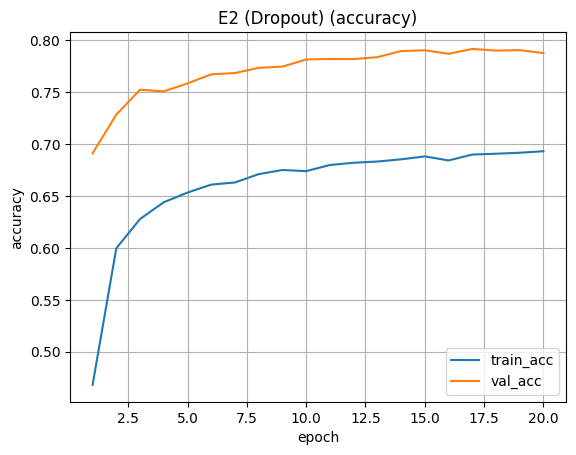

In [14]:
baseline_2 = MLP(hidden_dims=(128, 256, 128), dropout_p=0.3, use_batchnorm=False).to(device) # 3 скрытых слоя + dropout

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_2.parameters(), lr=1e-3)

history_baseline_2 = fit(
    baseline_2, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_baseline_2, title="E2 (Dropout)")

In [15]:
log_experiment("E2", dataset_name, baseline_2, history_baseline_2, 20)

E2 сохранён в artifacts/runs.csv, best_val_acc=0.7914 (epoch 17)


### E3 (BatchNorm)

epoch 01/20 | train loss=0.8967, acc=0.7356 | val loss=0.5629, acc=0.8151
epoch 02/20 | train loss=0.5455, acc=0.8161 | val loss=0.4933, acc=0.8399
epoch 03/20 | train loss=0.4753, acc=0.8355 | val loss=0.4669, acc=0.8432
epoch 04/20 | train loss=0.4351, acc=0.8467 | val loss=0.4491, acc=0.8483
epoch 05/20 | train loss=0.4063, acc=0.8539 | val loss=0.4357, acc=0.8505
epoch 06/20 | train loss=0.3847, acc=0.8610 | val loss=0.4457, acc=0.8513
epoch 07/20 | train loss=0.3638, acc=0.8668 | val loss=0.4383, acc=0.8533
epoch 08/20 | train loss=0.3481, acc=0.8710 | val loss=0.4466, acc=0.8541
epoch 09/20 | train loss=0.3321, acc=0.8760 | val loss=0.4371, acc=0.8538
epoch 10/20 | train loss=0.3173, acc=0.8803 | val loss=0.4425, acc=0.8564
epoch 11/20 | train loss=0.3064, acc=0.8831 | val loss=0.4336, acc=0.8582
epoch 12/20 | train loss=0.2945, acc=0.8869 | val loss=0.4367, acc=0.8567
epoch 13/20 | train loss=0.2891, acc=0.8873 | val loss=0.4491, acc=0.8569
epoch 14/20 | train loss=0.2795, acc=0

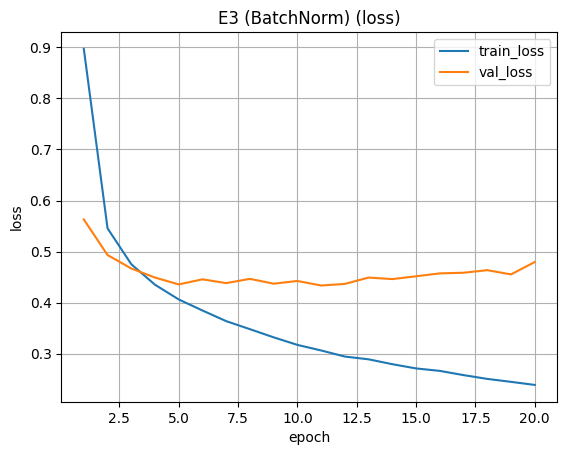

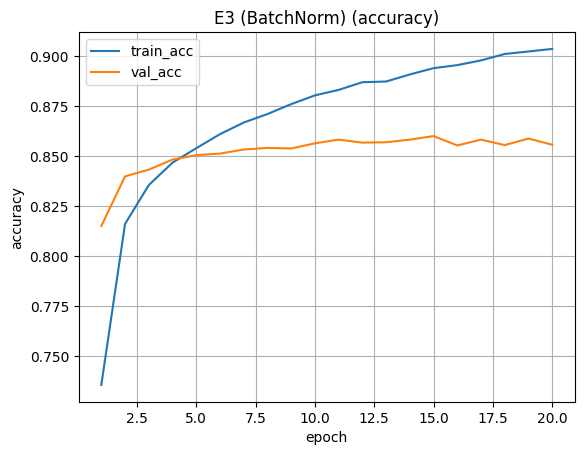

In [16]:
baseline_3 = MLP(hidden_dims=(128, 256, 128), dropout_p=0.0, use_batchnorm=True).to(device) # 3 скрытых слоя + batchnorm

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_3.parameters(), lr=1e-3)

history_baseline_3 = fit(
    baseline_3, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_baseline_3, title="E3 (BatchNorm)")

In [17]:
log_experiment("E3", dataset_name, baseline_3, history_baseline_3, 20)

E3 сохранён в artifacts/runs.csv, best_val_acc=0.8600 (epoch 15)


### E4 (EarlyStopping)

In [18]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

epoch 01/20 | train loss=0.8947, acc=0.7359 | val loss=0.5825, acc=0.8105
epoch 02/20 | train loss=0.5461, acc=0.8158 | val loss=0.4960, acc=0.8310
epoch 03/20 | train loss=0.4752, acc=0.8359 | val loss=0.4659, acc=0.8426
epoch 04/20 | train loss=0.4383, acc=0.8462 | val loss=0.4689, acc=0.8424
epoch 05/20 | train loss=0.4081, acc=0.8535 | val loss=0.4456, acc=0.8527
epoch 06/20 | train loss=0.3822, acc=0.8617 | val loss=0.4471, acc=0.8509
epoch 07/20 | train loss=0.3638, acc=0.8655 | val loss=0.4444, acc=0.8503
epoch 08/20 | train loss=0.3474, acc=0.8713 | val loss=0.4349, acc=0.8550
epoch 09/20 | train loss=0.3320, acc=0.8756 | val loss=0.4273, acc=0.8571
epoch 10/20 | train loss=0.3212, acc=0.8782 | val loss=0.4404, acc=0.8540
epoch 11/20 | train loss=0.3068, acc=0.8838 | val loss=0.4373, acc=0.8520
epoch 12/20 | train loss=0.2992, acc=0.8842 | val loss=0.4390, acc=0.8529
epoch 13/20 | train loss=0.2874, acc=0.8887 | val loss=0.4480, acc=0.8551
EarlyStopping: остановка на эпохе 13. 

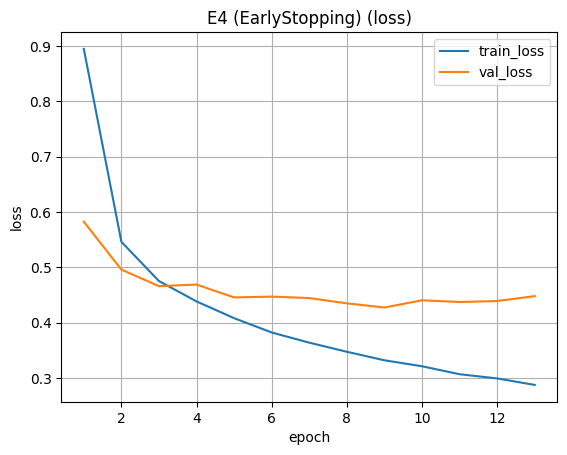

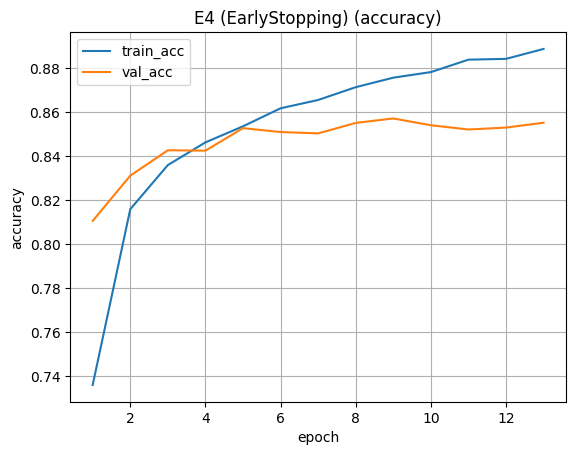

EarlyStopping test: loss=0.4552, acc=0.8489


In [19]:
baseline_4 = MLP(hidden_dims=(128, 256, 128), dropout_p=0.0, use_batchnorm=True).to(device) # 3 скрытых слоя + batchnorm
early_stopping = EarlyStopping(patience=4, min_delta=0.0005)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_4.parameters(), lr=1e-3)

history_baseline_4 = fit(
    baseline_4, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=early_stopping
)

plot_history(history_baseline_4, title="E4 (EarlyStopping)")
test_loss, test_acc = evaluate(baseline_4, test_loader, criterion, device)
print(f"EarlyStopping test: loss={test_loss:.4f}, acc={test_acc:.4f}")

In [20]:
log_experiment("E4", dataset_name, baseline_4, history_baseline_4, 20)

E4 сохранён в artifacts/runs.csv, best_val_acc=0.8571 (epoch 9)


In [21]:
torch.save(baseline_4.state_dict(), "artifacts/best_model.pt")
best_config = {
    "dataset": 'EMNIST (split="balanced")',
    "seed": 19,
    "hidden_sizes": [128, 256, 128],
    "n_classes": 47,
    "activation": "relu",
    "batchnorm": True,
    "dropout": 0.0,
    "optimizer": "Adam",
    "lr": 0.001,
    "momentum": 0.0,
    "weight_decay": 0.0,
    "epochs": len(history_baseline_4["train_loss"]),
    "batch_size": BATCH_SIZE,
    "early_stopping_patience": 5,
    "early_stopping_min_delta": 0.0001,
    "best_val_accuracy": max(history_baseline_4["val_acc"]),
    "test_accuracy": test_acc
}

with open("artifacts/best_config.json", "w", encoding="utf-8") as f:
    json.dump(best_config, f, indent=2, ensure_ascii=False)

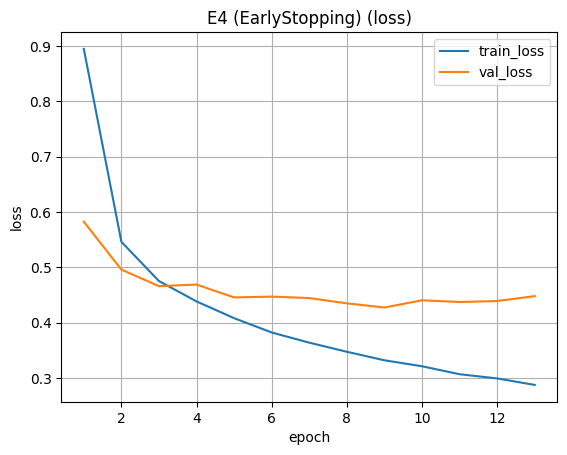

In [22]:
epochs = np.arange(1, len(history_baseline_4["train_loss"]) + 1)
title = "E4 (EarlyStopping)"

plt.figure()
plt.plot(epochs, history_baseline_4["train_loss"], label="train_loss")
plt.plot(epochs, history_baseline_4["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title((title + " (loss)") if title else "loss")
plt.legend()
plt.grid(True)
plt.savefig("artifacts/figures/curves_best.png")

## Часть B (S09): LR, оптимизаторы, weight decay 

### O1 (LR слишком большой)

epoch 01/8 | train loss=1.2345, acc=0.6279 | val loss=0.8854, acc=0.7242
epoch 02/8 | train loss=0.8805, acc=0.7237 | val loss=0.7119, acc=0.7627
epoch 03/8 | train loss=0.7902, acc=0.7509 | val loss=0.7070, acc=0.7826
epoch 04/8 | train loss=0.7420, acc=0.7642 | val loss=0.6731, acc=0.7865
epoch 05/8 | train loss=0.6975, acc=0.7763 | val loss=0.6443, acc=0.8052
epoch 06/8 | train loss=0.6668, acc=0.7857 | val loss=0.6829, acc=0.7885
epoch 07/8 | train loss=0.6448, acc=0.7905 | val loss=0.6647, acc=0.7823
epoch 08/8 | train loss=0.6328, acc=0.7956 | val loss=0.6363, acc=0.7993


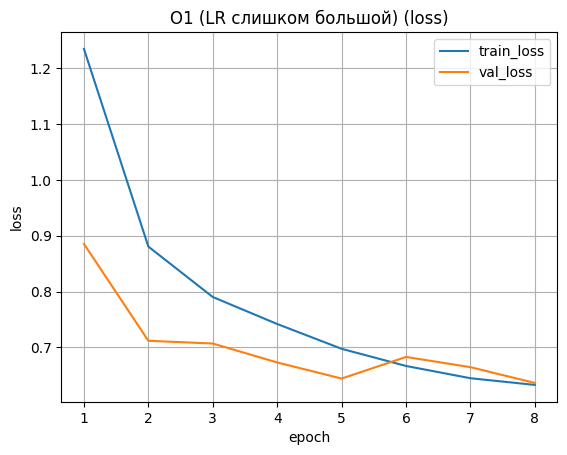

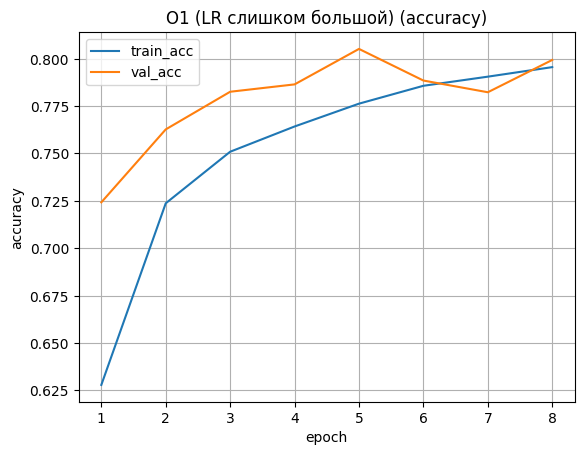

In [24]:
baseline_o1 = MLP(hidden_dims=(128, 256, 128), dropout_p=0.0, use_batchnorm=True).to(device) # 3 скрытых слоя + batchnorm
early_stopping = EarlyStopping(patience=4, min_delta=0.0005)

optimizer_o1 = optim.Adam(baseline_o1.parameters(), lr=0.1)
history_o1 = fit(baseline_o1, train_loader, val_loader, optimizer_o1, criterion, device, epochs=8)

plot_history(history_o1, title="O1 (LR слишком большой)")

In [25]:
log_experiment("O1", dataset_name, baseline_o1, history_o1, 8, optimizer_o1)

O1 сохранён в artifacts/runs.csv, best_val_acc=0.8052 (epoch 5)


### O2 (LR слишком маленький)

epoch 01/8 | train loss=3.3752, acc=0.2174 | val loss=2.9484, acc=0.4024
epoch 02/8 | train loss=2.6828, acc=0.4706 | val loss=2.4086, acc=0.5413
epoch 03/8 | train loss=2.2363, acc=0.5629 | val loss=2.0187, acc=0.6008
epoch 04/8 | train loss=1.9006, acc=0.6165 | val loss=1.7434, acc=0.6444
epoch 05/8 | train loss=1.6450, acc=0.6531 | val loss=1.5070, acc=0.6759
epoch 06/8 | train loss=1.4513, acc=0.6785 | val loss=1.3460, acc=0.6948
epoch 07/8 | train loss=1.2985, acc=0.6984 | val loss=1.2126, acc=0.7146
epoch 08/8 | train loss=1.1825, acc=0.7138 | val loss=1.1058, acc=0.7280


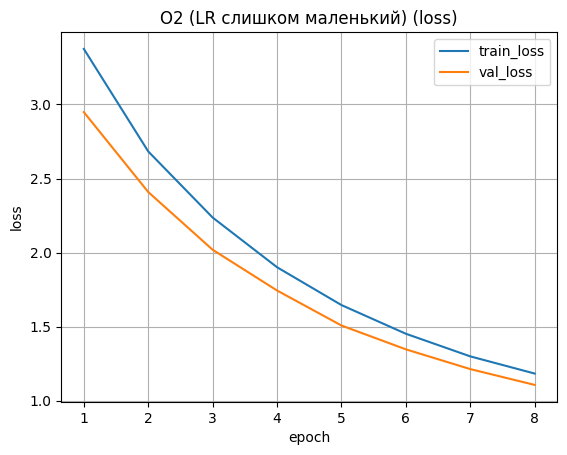

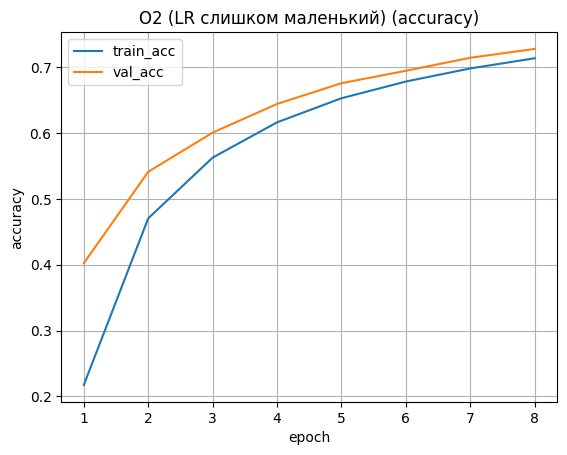

In [26]:
baseline_o2 = MLP(hidden_dims=(128, 256, 128), dropout_p=0.0, use_batchnorm=True).to(device) # 3 скрытых слоя + batchnorm
early_stopping = EarlyStopping(patience=4, min_delta=0.0005)

optimizer_o2 = optim.Adam(baseline_o2.parameters(), lr=0.00001)
history_o2 = fit(baseline_o2, train_loader, val_loader, optimizer_o2, criterion, device, epochs=8)

plot_history(history_o2, title="O2 (LR слишком маленький)")

In [27]:
log_experiment("O2", dataset_name, baseline_o2, history_o2, 8, optimizer_o2)

O2 сохранён в artifacts/runs.csv, best_val_acc=0.7280 (epoch 8)


### O3 (SGD + momentum + weight decay)

epoch 01/12 | train loss=1.7991, acc=0.5874 | val loss=0.9988, acc=0.7366
epoch 02/12 | train loss=0.8624, acc=0.7567 | val loss=0.7145, acc=0.7895
epoch 03/12 | train loss=0.6836, acc=0.7927 | val loss=0.6159, acc=0.8106
epoch 04/12 | train loss=0.5950, acc=0.8136 | val loss=0.5676, acc=0.8234
epoch 05/12 | train loss=0.5449, acc=0.8257 | val loss=0.5357, acc=0.8304
epoch 06/12 | train loss=0.5048, acc=0.8359 | val loss=0.5098, acc=0.8378
epoch 07/12 | train loss=0.4771, acc=0.8413 | val loss=0.4931, acc=0.8400
epoch 08/12 | train loss=0.4534, acc=0.8486 | val loss=0.4826, acc=0.8415
epoch 09/12 | train loss=0.4332, acc=0.8530 | val loss=0.4723, acc=0.8473
epoch 10/12 | train loss=0.4165, acc=0.8578 | val loss=0.4683, acc=0.8445
epoch 11/12 | train loss=0.4048, acc=0.8606 | val loss=0.4590, acc=0.8480
epoch 12/12 | train loss=0.3922, acc=0.8639 | val loss=0.4619, acc=0.8469


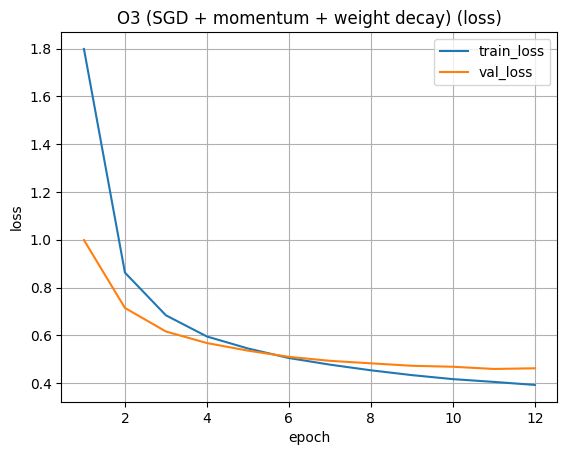

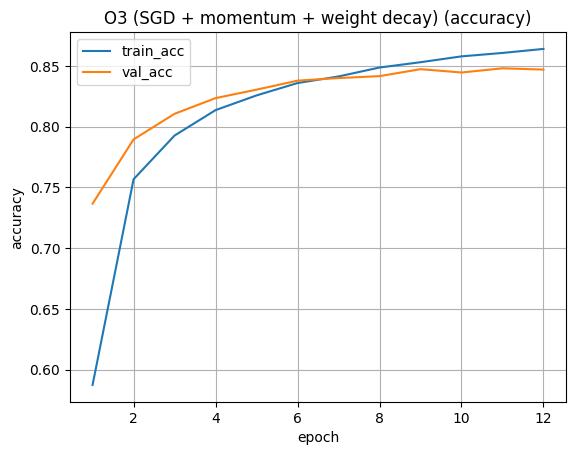

In [28]:
baseline_o3 = MLP(hidden_dims=(128, 256, 128), dropout_p=0.0, use_batchnorm=True).to(device) # 3 скрытых слоя + batchnorm
early_stopping = EarlyStopping(patience=4, min_delta=0.0005)

optimizer_o3 = optim.SGD(baseline_o3.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)
history_o3 = fit(baseline_o3, train_loader, val_loader, optimizer_o3, criterion, device, epochs=12)

plot_history(history_o3, title="O3 (SGD + momentum + weight decay)")

In [29]:
log_experiment("O3", dataset_name, baseline_o3, history_o3, 12, optimizer_o3)

O3 сохранён в artifacts/runs.csv, best_val_acc=0.8480 (epoch 11)


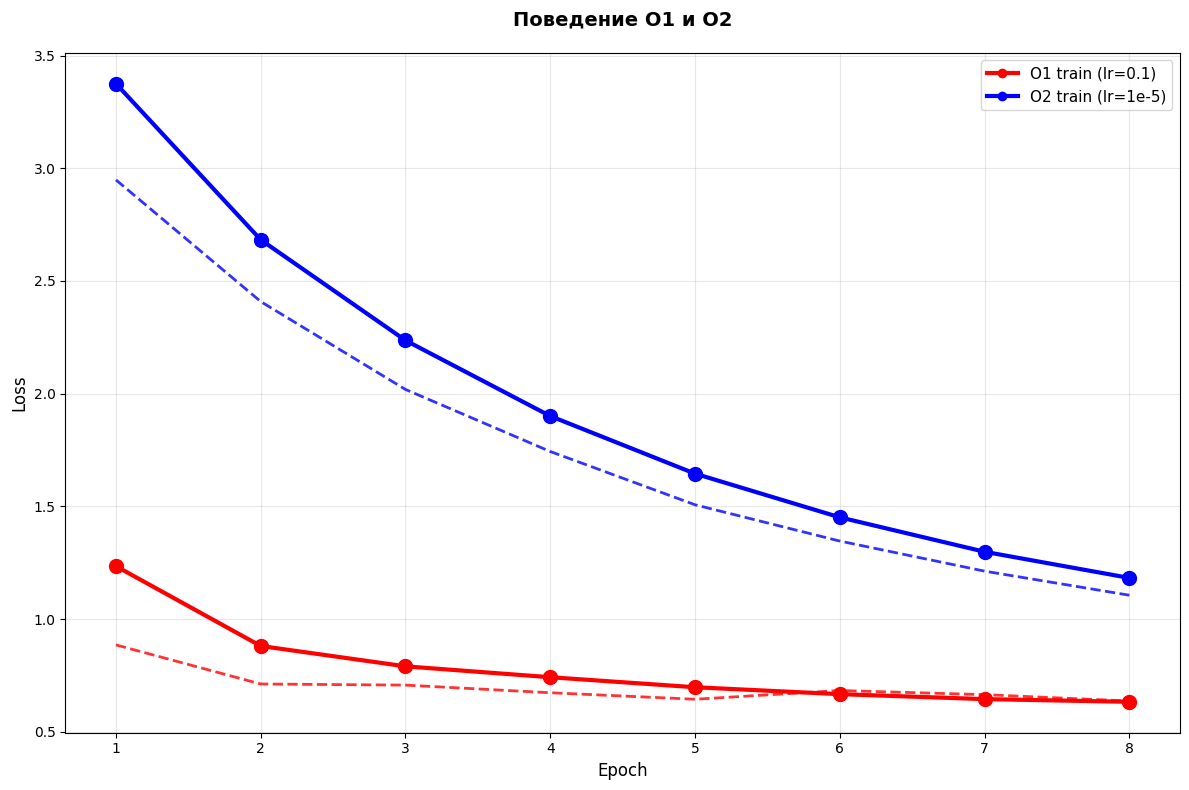

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Нормализуем эпохи для наложения
max_epochs = max(len(history_o1["train_loss"]), len(history_o2["train_loss"]))
epochs_o1 = np.arange(1, len(history_o1["train_loss"]) + 1)
epochs_o2 = np.arange(1, len(history_o2["train_loss"]) + 1)

# O1 (lr=0.1)
ax.plot(epochs_o1, history_o1["train_loss"], 'r-o', label="O1 train (lr=0.1)", linewidth=3, markersize=6)
ax.plot(epochs_o1, history_o1["val_loss"], 'r--', alpha=0.8, linewidth=2)
ax.scatter(epochs_o1, history_o1["train_loss"], color='red', s=100, zorder=5)

# O2 (lr=1e-5)
ax.plot(epochs_o2, history_o2["train_loss"], 'b-o', label="O2 train (lr=1e-5)", linewidth=3, markersize=6)
ax.plot(epochs_o2, history_o2["val_loss"], 'b--', alpha=0.8, linewidth=2)
ax.scatter(epochs_o2, history_o2["train_loss"], color='blue', s=100, zorder=5)

ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("Поведение O1 и O2", 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("artifacts/figures/curves_lr_extremes.png")

In [31]:
import sys
print('python:', sys.version)
print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)

python: 3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]
torch: 2.10.0+cpu
torchvision: 0.25.0+cpu
